In [1]:
#importing all the libraries we need for this project

import numpy as np  # Importing NumPy for numerical operations and array manipulations
import matplotlib.pyplot as plt  # Importing Matplotlib for plotting graphs and visualizations
import seaborn as sns  # Importing Seaborn for statistical data visualization, built on top of Matplotlib
import tensorflow as tf  # Importing TensorFlow for building and training machine learning models
from tensorflow import keras  # Importing Keras, a high-level API for TensorFlow, to simplify model building
from tensorflow.keras.layers import Layer  # Importing Layer class for creating custom layers in Keras
from tensorflow.keras.models import Sequential  # Importing Sequential model for building neural networks layer-by-layer
from tensorflow.keras.layers import Rescaling , GlobalAveragePooling2D
from tensorflow.keras import layers, optimizers, callbacks  # Importing various modules for layers, optimizers, and callbacks in Keras
from sklearn.utils.class_weight import compute_class_weight  # Importing function to compute class weights for imbalanced datasets
from tensorflow.keras.applications import EfficientNetV2B2  # Importing EfficientNetV2S model for transfer learning
from sklearn.metrics import confusion_matrix, classification_report  # Importing functions to evaluate model performance
import gradio as gr  # Importing Gradio for creating interactive web interfaces for machine learning models

In [2]:
#loading images from folders, resizing to 124×124, and splitting them 80% for training and 20% for validation

dataset_dir= r"C:\Users\E VAHINI\AICTE_Project\Shell Edunet AICTE Internship Dataset\TrashType_Image_Dataset" #path to my dataset
image_size = (124, 124)  # Resize all images to 124x124 pixels
batch_size = 32          # Load 32 images at a time (good for training speed/memory)
seed = 42                # Seed for reproducibility

In [3]:
#Creating the Training Dataset

train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split = 0.2,
    subset = "training",
    seed = seed,
    shuffle = True,
    image_size = image_size,
    batch_size = batch_size
)

Found 2527 files belonging to 6 classes.
Using 2022 files for training.


In [4]:
#Creating the Validation Dataset

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split = 0.2,
    subset = "validation",
    seed = seed,
    shuffle = True,
    image_size = image_size,
    batch_size = batch_size
)

#Get Class Names
#This stores the class names (i.e., subfolder names like metal, glass, etc.)
val_class = val_ds.class_names

Found 2527 files belonging to 6 classes.
Using 505 files for validation.


In [5]:

# Get the total number of batches in the validation dataset
val_batches = tf.data.experimental.cardinality(val_ds)  

# Split the validation dataset into two equal parts:
# First half becomes the test dataset
test_ds = val_ds.take(val_batches // 2)  

# Second half remains as the validation dataset
val_dat = val_ds.skip(val_batches // 2)  

#train_ds = 80% (original training), val_dat = 10% (real validation), test_ds = 10% (final evaluation/test)

# Optimize test dataset by caching and prefetching to improve performance
test_ds_eval = test_ds.cache().prefetch(tf.data.AUTOTUNE)  


In [6]:
#Printing Information
print(train_ds.class_names)
print(val_class)
print(len(train_ds.class_names))

['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
6


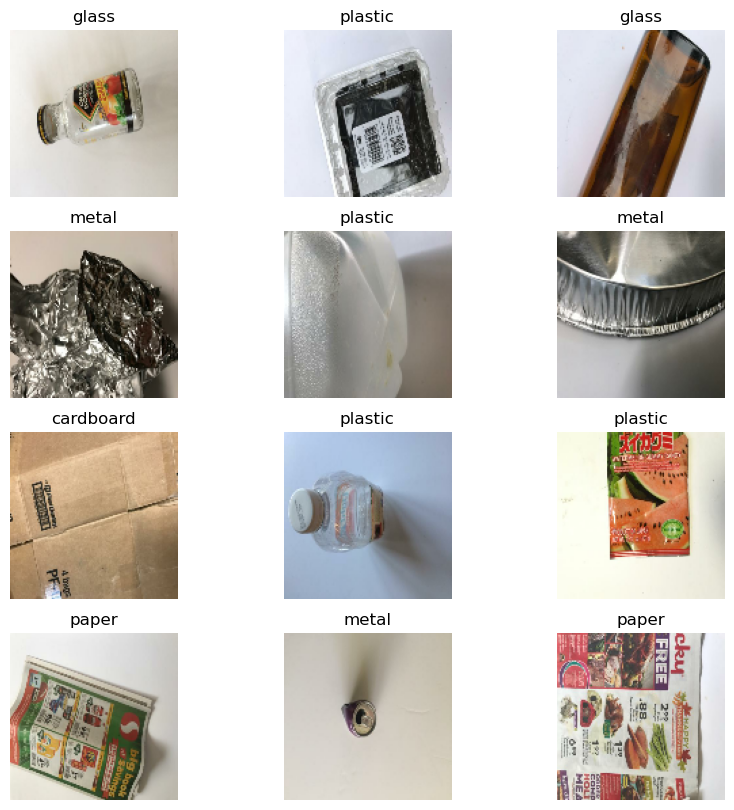

In [7]:
#visualizing sample images from your training dataset (train_ds).

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
  for i in range(12):
    ax = plt.subplot(4, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(train_ds.class_names[labels[i]])
    plt.axis("off")

In [8]:
#count_distribution() Function
#This function calculates the percentage of each class in a given dataset (like train_ds, val_ds, or test_ds).
def count_distribution(dataset, class_names):
    total = 0
    counts = {name: 0 for name in class_names}
    
    for _, labels in dataset:
        for label in labels.numpy():
            class_name = class_names[label]
            counts[class_name] += 1
            total += 1

    for k in counts:
        counts[k] = round((counts[k] / total) * 100, 2)  # Convert to percentage
    return counts

In [9]:
#simple_bar_plot() Function #Plots a bar graph showing how many images (in %) each class has.

#Function to plot class distribution
def simple_bar_plot(dist, title):
    plt.bar(dist.keys(), dist.values(), color='cornflowerblue')
    plt.title(title)
    plt.ylabel('Percentage (%)')
    plt.xticks(rotation=45)
    plt.ylim(0, 100)
    plt.tight_layout()
    plt.show()

In [10]:
#Calculate Distributions for Each Set
class_names = train_ds.class_names

# Get class distributions
train_dist = count_distribution(train_ds, class_names)
val_dist = count_distribution(val_ds, class_names)
test_dist = count_distribution(test_ds, class_names)

#Calculate Overall Distribution
overall_dist = {}
for k in class_names:
    overall_dist[k] = round((train_dist[k] + val_dist[k]) / 2, 2)

#Display Results
print(train_dist)
print(val_dist)
print(test_dist)
print(overall_dist)

{'cardboard': 16.52, 'glass': 19.73, 'metal': 15.92, 'paper': 23.29, 'plastic': 19.44, 'trash': 5.09}
{'cardboard': 13.66, 'glass': 20.2, 'metal': 17.43, 'paper': 24.36, 'plastic': 17.62, 'trash': 6.73}
{'cardboard': 14.06, 'glass': 17.58, 'metal': 16.8, 'paper': 25.0, 'plastic': 19.14, 'trash': 7.42}
{'cardboard': 15.09, 'glass': 19.96, 'metal': 16.68, 'paper': 23.82, 'plastic': 18.53, 'trash': 5.91}


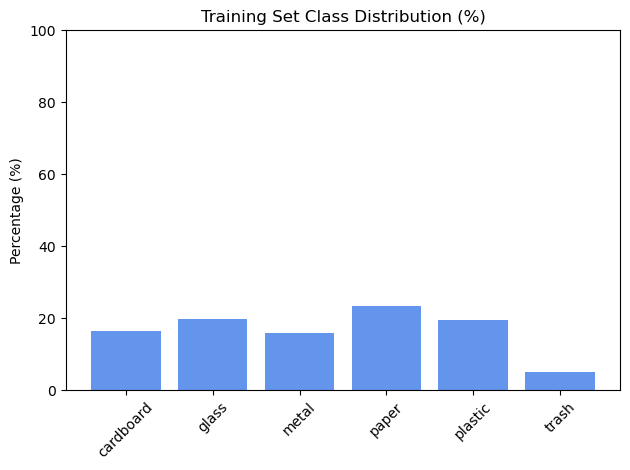

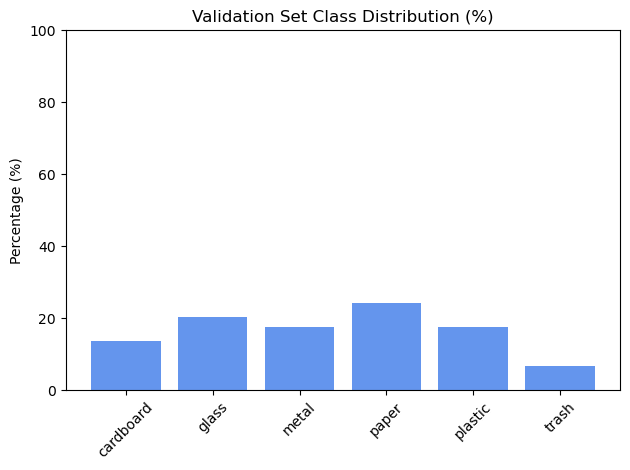

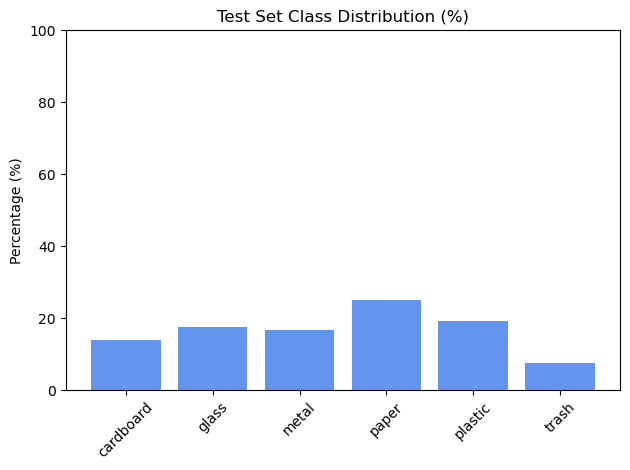

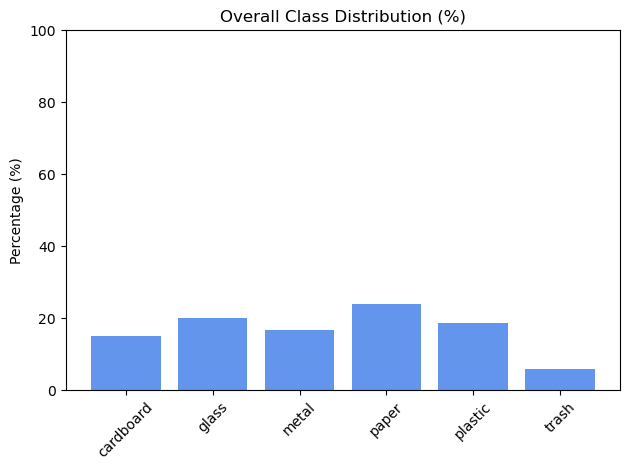

In [11]:
#Show visualizations
#Visualize Class Distribution
simple_bar_plot(train_dist, "Training Set Class Distribution (%)")
simple_bar_plot(val_dist, "Validation Set Class Distribution (%)")
simple_bar_plot(test_dist, "Test Set Class Distribution (%)")
simple_bar_plot(overall_dist, "Overall Class Distribution (%)")


In [12]:
# Count class occurrences and prepare label list
class_counts = {i: 0 for i in range(len(class_names))}
all_labels = []

for images, labels in train_ds:
    for label in labels.numpy():
        class_counts[label] += 1
        all_labels.append(label)

#Compute class weights for Imbalanced Data (index aligned) 
class_weights_array = compute_class_weight(
    class_weight = 'balanced',
    classes = np.arange(len(class_names)),
    y = all_labels
)

# Create dictionary mapping class index to weight
class_weights = {i: w for i, w in enumerate(class_weights_array)}  # Convert Weights to Dictionary Format

In [13]:
# ✅ Optional: print results
# Prints the actual image count per class and the computed class weights so we can check if it's working correctly.

print("Class Counts:", class_counts)
print("Class Weights:", class_weights)


Class Counts: {0: 334, 1: 399, 2: 322, 3: 471, 4: 393, 5: 103}
Class Weights: {0: 1.0089820359281436, 1: 0.8446115288220551, 2: 1.046583850931677, 3: 0.7154989384288747, 4: 0.8575063613231552, 5: 3.2718446601941746}


In [14]:
#  Define data augmentation pipeline
data_augmentation = Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])

In [15]:
#  Load the pretrained MobileNetV3Small model (without the top classification layer)
base_model = EfficientNetV2B2(
    include_top = False,
    input_shape = (124, 124, 3),
    include_preprocessing = True,
    weights = 'imagenet')


#  Freeze early layers (to retain general pretrained features)
base_model.trainable = True
for layer in base_model.layers[:100]:  # You can adjust this number
    layer.trainable = False

In [16]:
#  Build the final model
model = Sequential([
    layers.Input(shape=(124, 124, 3)),
    data_augmentation,
    base_model,
    GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(6, activation='softmax')  # Change to your number of classes (# 6 = number of classes)
])

In [17]:
# ⚙️ Compile the model
model.compile(
    optimizer = optimizers.Adam(learning_rate=1e-4),
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

In [18]:
# Define an EarlyStopping callback to stop training when validation loss stops improving
early = tf.keras.callbacks.EarlyStopping(
    monitor = 'val_loss',            # Metric to monitor (validation loss here)
    patience = 3,                   # Number of epochs to wait after last improvement before stopping
    restore_best_weights = True     # After stopping, restore the model weights from the epoch with the best val_loss
)

In [27]:
# Set the number of epochs to train the model
epochs = 10  # Number of times the model will go through the entire dataset

# Train the model using the fit function
history = model.fit(  
    train_ds,                # Training dataset used to adjust model weights
    validation_data=val_ds,   # Validation dataset to monitor performance on unseen data
    epochs=epochs,           # Number of training cycles, referencing the variable set earlier
    class_weight=class_weights,  # Handles class imbalances by assigning appropriate weights
    batch_size=32,           # Number of samples processed in each training step
    callbacks=[early]        # Implements early stopping to prevent unnecessary training
)

Epoch 1/10
64/64 [==============================] - 45s 696ms/step - loss: 0.0263 - accuracy: 0.9921 - val_loss: 0.2305 - val_accuracy: 0.9188
Epoch 2/10
64/64 [==============================] - 47s 741ms/step - loss: 0.0310 - accuracy: 0.9911 - val_loss: 0.2721 - val_accuracy: 0.9089
Epoch 3/10
64/64 [==============================] - 46s 722ms/step - loss: 0.0323 - accuracy: 0.9911 - val_loss: 0.2765 - val_accuracy: 0.9069
Epoch 4/10
64/64 [==============================] - 47s 730ms/step - loss: 0.0258 - accuracy: 0.9926 - val_loss: 0.2490 - val_accuracy: 0.9188


In [28]:
# Fix class_weights to reindex from 0
label_mapping = {label: idx for idx, label in enumerate(sorted(set(all_labels)))}
mapped_labels = [label_mapping[label] for label in all_labels]

from sklearn.utils.class_weight import compute_class_weight

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(len(label_mapping)),
    y=mapped_labels
)

class_weights = {i: w for i, w in enumerate(class_weights_array)}


In [29]:
# 📝 Summary (optional but useful)
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential (Sequential)     (None, 124, 124, 3)       0         
                                                                 
 efficientnetv2-b2 (Function  (None, 4, 4, 1408)       8769374   
 al)                                                             
                                                                 
 global_average_pooling2d (G  (None, 1408)             0         
 lobalAveragePooling2D)                                          
                                                                 
 dropout (Dropout)           (None, 1408)              0         
                                                                 
 dense (Dense)               (None, 6)                 8454      
                                                                 
Total params: 8,777,828
Trainable params: 7,974,642
No

In [30]:
base_model.summary() # Print the architecture summary of the base model

Model: "efficientnetv2-b2"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 124, 124, 3  0           []                               
                                )]                                                                
                                                                                                  
 rescaling (Rescaling)          (None, 124, 124, 3)  0           ['input_1[0][0]']                
                                                                                                  
 normalization (Normalization)  (None, 124, 124, 3)  0           ['rescaling[0][0]']              
                                                                                                  
 stem_conv (Conv2D)             (None, 62, 62, 32)   864         ['normalization[0

Epoch 1/10
64/64 [==============================] - 56s 733ms/step - loss: 0.0443 - accuracy: 0.9832 - val_loss: 0.2224 - val_accuracy: 0.9287
Epoch 2/10
64/64 [==============================] - 45s 696ms/step - loss: 0.0436 - accuracy: 0.9852 - val_loss: 0.2732 - val_accuracy: 0.9149
Epoch 3/10
64/64 [==============================] - 46s 724ms/step - loss: 0.0399 - accuracy: 0.9881 - val_loss: 0.2831 - val_accuracy: 0.9109
Epoch 4/10
64/64 [==============================] - 45s 706ms/step - loss: 0.0346 - accuracy: 0.9891 - val_loss: 0.2678 - val_accuracy: 0.9188
Epoch 5/10
64/64 [==============================] - 50s 787ms/step - loss: 0.0342 - accuracy: 0.9896 - val_loss: 0.2707 - val_accuracy: 0.9188
Epoch 6/10
64/64 [==============================] - 47s 730ms/step - loss: 0.0246 - accuracy: 0.9941 - val_loss: 0.2953 - val_accuracy: 0.9109
Epoch 7/10
64/64 [==============================] - 46s 726ms/step - loss: 0.0310 - accuracy: 0.9916 - val_loss: 0.2541 - val_accuracy: 0.9267

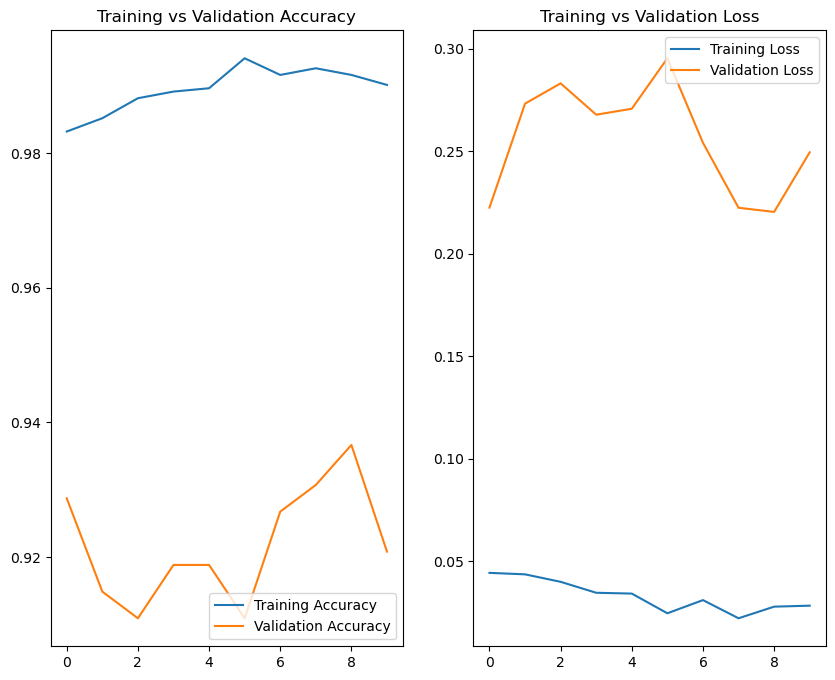

In [31]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

acc = history.history['accuracy']          # Extract training accuracy from history
val_acc = history.history['val_accuracy']  # Extract validation accuracy from history
loss = history.history['loss']             # Extract training loss from history
val_loss = history.history['val_loss']     # Extract validation loss from history

epochs_range = range(len(acc))             # Define range for epochs based on accuracy length

plt.figure(figsize=(10,8))                 # Set overall figure size for visualization

plt.subplot(1,2,1)                         # Create first subplot (1 row, 2 columns, position 1)
plt.plot(epochs_range, acc, label='Training Accuracy')       # Plot training accuracy
plt.plot(epochs_range, val_acc, label='Validation Accuracy') # Plot validation accuracy
plt.legend(loc='lower right')              # Place legend in lower-right corner
plt.title('Training vs Validation Accuracy') # Add title for accuracy plot

plt.subplot(1,2,2)                         # Create second subplot (1 row, 2 columns, position 2)
plt.plot(epochs_range, loss, label='Training Loss')         # Plot training loss
plt.plot(epochs_range, val_loss, label='Validation Loss')   # Plot validation loss
plt.legend(loc='upper right')              # Place legend in upper-right corner
plt.title('Training vs Validation Loss')   # Add title for loss plot

plt.show()                                 # Display the plots

In [34]:
#Modal Evaluation 
loss, accuracy = model.evaluate(test_ds_eval)
print(f'Test accuracy is{accuracy:.4f}, Test loss is {loss:.4f}')

8/8 [==============================] - 2s 187ms/step - loss: 0.2566 - accuracy: 0.9219
Test accuracy is0.9219, Test loss is 0.2566


In [35]:
# Extract true labels from all batches in the test dataset
y_true = np.concatenate([y.numpy() for x, y in test_ds_eval], axis=0)  # Convert Tensor labels to NumPy array and concatenate them

# Get predictions as probabilities from the model
y_pred_probs = model.predict(test_ds_eval)  # Predict class probabilities for each sample in the test dataset

# Convert probabilities to predicted class indices
y_pred = np.argmax(y_pred_probs, axis=1)  # Select the class with the highest probability for each sample

# Compute the confusion matrix to evaluate classification performance
cm = confusion_matrix(y_true, y_pred)  # Generate confusion matrix comparing true labels to predicted labels

# Print metrics to assess model performance
print(cm)  # Display confusion matrix
print(classification_report(y_true, y_pred))  # Print precision, recall, and F1-score for each class

8/8 [==============================] - 3s 204ms/step
[[28  0  1  2  0  0]
 [ 0 50  6  0  2  0]
 [ 0  0 41  0  0  1]
 [ 2  0  0 54  0  0]
 [ 0  0  1  1 50  1]
 [ 0  1  0  1  1 13]]
              precision    recall  f1-score   support

           0       0.93      0.90      0.92        31
           1       0.98      0.86      0.92        58
           2       0.84      0.98      0.90        42
           3       0.93      0.96      0.95        56
           4       0.94      0.94      0.94        53
           5       0.87      0.81      0.84        16

    accuracy                           0.92       256
   macro avg       0.92      0.91      0.91       256
weighted avg       0.93      0.92      0.92       256



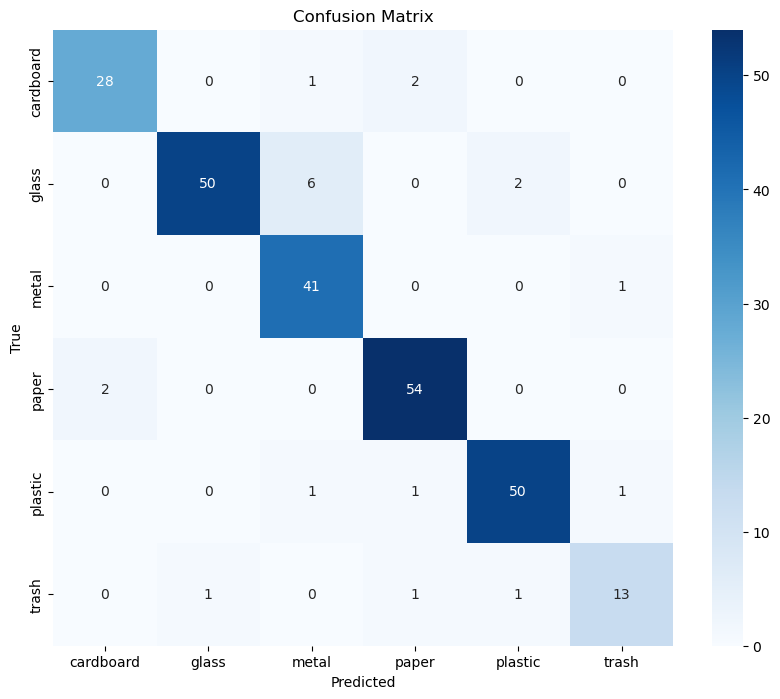

In [36]:
plt.figure(figsize=(10,8))  # Set figure size for better visualization

sns.heatmap(cm, annot=True, fmt='d',  # Create heatmap using confusion matrix
            xticklabels=class_names,  # Set class names for x-axis (predicted labels)
            yticklabels=class_names,  # Set class names for y-axis (true labels)
            cmap='Blues')  # Use a blue colormap for better contrast

plt.xlabel('Predicted')  # Label x-axis as Predicted classes
plt.ylabel('True')  # Label y-axis as True classes
plt.title('Confusion Matrix')  # Add title to the heatmap
plt.show()  # Display the plot

1/1 [==============================] - 6s 6s/step


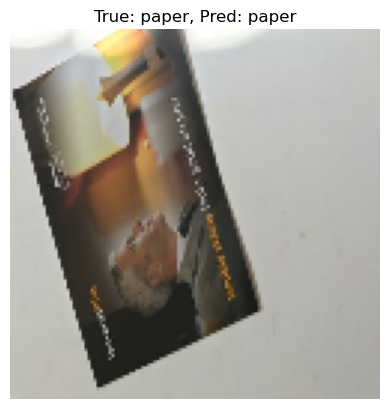

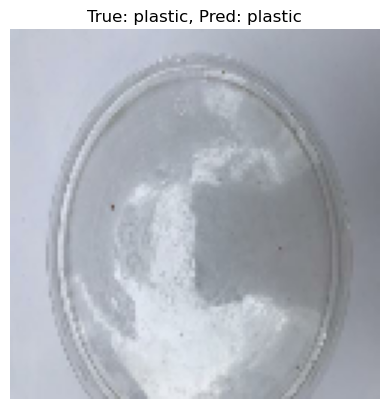

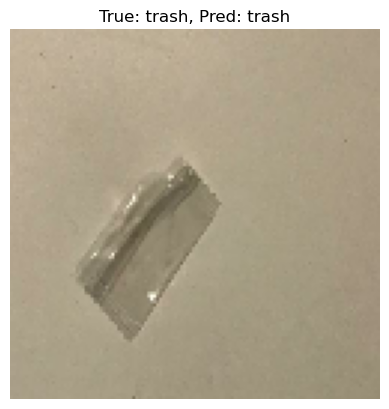

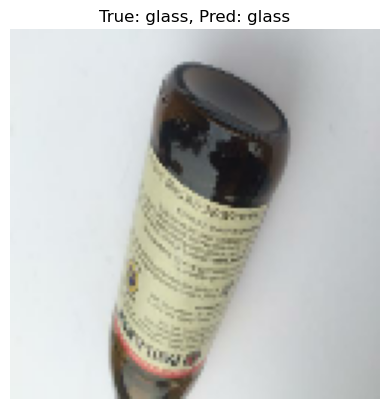

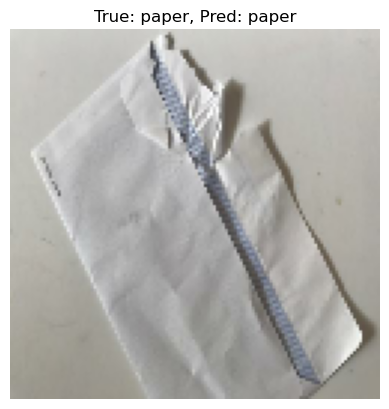

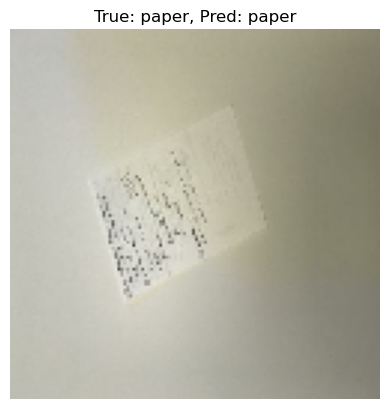

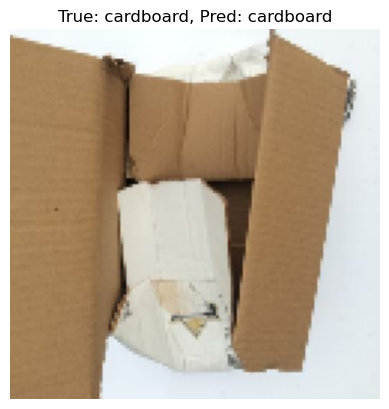

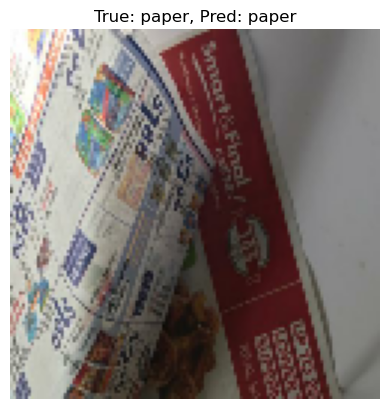

In [49]:
# Extract class names from the training dataset
class_names = train_ds.class_names  

# Take one batch of images and labels from the test dataset for evaluation
for images, labels in test_ds_eval.take(1):  

    # Generate predictions for the batch of images
    predictions = model.predict(images)  

    # Get the predicted class index for each image
    pred_labels = tf.argmax(predictions, axis=1)  

    # Loop through the first 8 images in the batch
    for i in range(8):  
        plt.imshow(images[i].numpy().astype("uint8"))  # Convert and display image
        plt.title(f"True: {class_names[labels[i]]}, Pred: {class_names[pred_labels[i]]}")  # Show actual and predicted class
        plt.axis("off")  # Hide axes for better visualization
        plt.show()  # Display the image with title

In [37]:
# Save model in Keras format with architecture, weights, and training configuration
model.save('Effiicientnetv2b2.keras')

# Load your Keras model
model = tf.keras.models.load_model('Effiicientnetv2b2.keras')

In [43]:
# Modal Deployment using Gradio with my trained model.
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input

In [44]:
def classify_image(img):  
    # Resize image to 124x124 pixels (Note: Comment says 128x128, but code resizes to 124x124)
    img = img.resize((124, 124))  
    
    # Convert image to a NumPy array with float32 dtype
    img_array = np.array(img, dtype=np.float32)  
    img_array = preprocess_input(img_array)
    
    # Expand dimensions to match model input shape (adds a batch dimension)
    img_array = np.expand_dims(img_array, axis=0)  
    
    # Make a prediction using the trained model
    prediction = model.predict(img_array)  
    
    # Get the index of the highest predicted probability
    predicted_class_index = np.argmax(prediction)  
    
    # Map the predicted index to its corresponding class name
    predicted_class_name = class_names[predicted_class_index]  
    
    # Extract confidence score (probability of the predicted class)
    confidence = prediction[0][predicted_class_index]  
    
    # Return formatted prediction result with confidence score
    return f"Predicted: {predicted_class_name} (Confidence: {confidence:.2f})"  

In [45]:
iface = gr.Interface(  
    fn=classify_image,  # Function to classify image using the trained model  
    inputs= gr.Image(type="pil"),  # Accepts input as a PIL image  
    outputs="text"  # Outputs prediction as text  
)  

# Launch the interface  
iface.launch()  # Start the Gradio interface for user interaction 

* Running on local URL:  http://127.0.0.1:7863
* To create a public link, set `share=True` in `launch()`.


1/1 [==============================] - 0s 46ms/step
